# OLS Linear Regression

**Flow:** observations → best-fit line → residuals → held-out R² → cross-validation.

Ordinary least squares (OLS) chooses coefficients that minimize the **sum of squared vertical residuals**. It is a baseline, not proof that a relationship is causal.

## 1. Setup and versions
We import only what we use and print library versions so the results are reproducible. A single colorblind-safe palette (Okabe–Ito) is used for categorical series throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor

rng = np.random.default_rng(42)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]


In [2]:
# Environment / version info for reproducibility
import sys
import numpy as np
import scipy
import sklearn
import matplotlib

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. Generate data and split BEFORE fitting
We create a deterministic synthetic dataset, then split into a training set and a held-out test set **before** fitting anything. The model never sees the test rows during training.

In [3]:
# Deterministic synthetic data: y = 3 + 1.8 x + noise
x = np.linspace(0, 10, 60)
y = 3 + 1.8 * x + rng.normal(0, 2, size=x.size)
X = x[:, None]  # scikit-learn expects a 2-D feature matrix

# Split BEFORE fitting so evaluation uses only held-out data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples    : {X_test.shape[0]}')


Training samples: 42
Test samples    : 18


## 3. Fit on training data, inspect the fit and residuals
The left panel shows the fitted line over the **training** data. The right panel shows residuals versus fitted values: a good OLS fit shows residuals scattered around zero with no pattern.

Estimated slope     : 1.809 (true 1.8)
Estimated intercept : 3.216 (true 3.0)


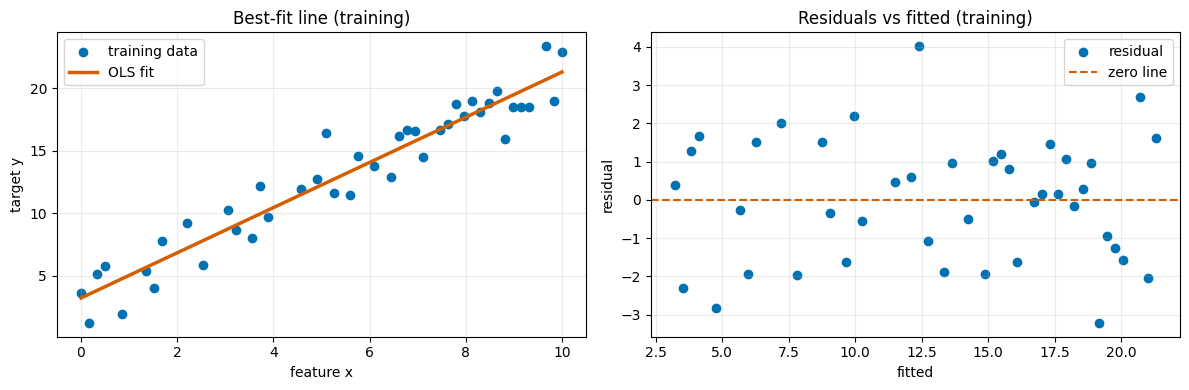

In [4]:
ols = LinearRegression().fit(X_train, y_train)
train_pred = ols.predict(X_train)
train_resid = y_train - train_pred

print(f'Estimated slope     : {ols.coef_[0]:.3f} (true 1.8)')
print(f'Estimated intercept : {ols.intercept_:.3f} (true 3.0)')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(X_train[:, 0], y_train, color=OKABE_ITO[0],
              label='training data')
order = np.argsort(X_train[:, 0])
ax[0].plot(X_train[order, 0], train_pred[order], color=OKABE_ITO[3],
           lw=2.5, label='OLS fit')
ax[0].set(title='Best-fit line (training)', xlabel='feature x',
          ylabel='target y')
ax[0].legend(); ax[0].grid(alpha=0.25)

ax[1].scatter(train_pred, train_resid, color=OKABE_ITO[0],
              label='residual')
ax[1].axhline(0, color=OKABE_ITO[3], ls='--', label='zero line')
ax[1].set(title='Residuals vs fitted (training)', xlabel='fitted',
          ylabel='residual')
ax[1].legend(); ax[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


## 4. Evaluate on held-out test data with a mean baseline
R² compares the model against a **mean baseline** (predicting the training mean for every row). R² can be **negative** on unseen data when the model does worse than that baseline. We report the baseline explicitly so the sign of R² is interpretable.

model                  R2         MSE       MAE
-----------------------------------------------
Mean baseline      -0.532      31.648     4.723
OLS model           0.896       2.146     1.118


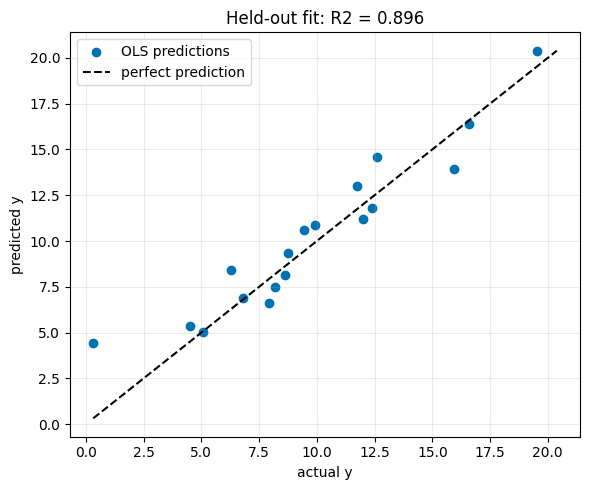

In [5]:
test_pred = ols.predict(X_test)

# Mean baseline: always predict the training mean.
baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
base_pred = baseline.predict(X_test)

rows = [
    ('Mean baseline', r2_score(y_test, base_pred),
     mean_squared_error(y_test, base_pred),
     mean_absolute_error(y_test, base_pred)),
    ('OLS model', r2_score(y_test, test_pred),
     mean_squared_error(y_test, test_pred),
     mean_absolute_error(y_test, test_pred)),
]
print(f'{"model":<15}{"R2":>10}{"MSE":>12}{"MAE":>10}')
print('-' * 47)
for name, r2, mse, mae in rows:
    print(f'{name:<15}{r2:>10.3f}{mse:>12.3f}{mae:>10.3f}')

lim = [min(y_test.min(), test_pred.min()),
       max(y_test.max(), test_pred.max())]
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred, color=OKABE_ITO[0], label='OLS predictions')
plt.plot(lim, lim, color='black', ls='--', label='perfect prediction')
plt.title(f'Held-out fit: R2 = {r2_score(y_test, test_pred):.3f}')
plt.xlabel('actual y'); plt.ylabel('predicted y')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 5. Cross-validation on training data
A single split can be lucky or unlucky. Cross-validation on the **training** data estimates how stable the generalization is. We keep the test set untouched for a final, single evaluation.

5-fold CV R2 on training data:
  fold 1: 0.863
  fold 2: 0.891
  fold 3: 0.939
  fold 4: 0.855
  fold 5: 0.929
  mean : 0.895 +/- 0.034

Final held-out test R2 (reported once): 0.896


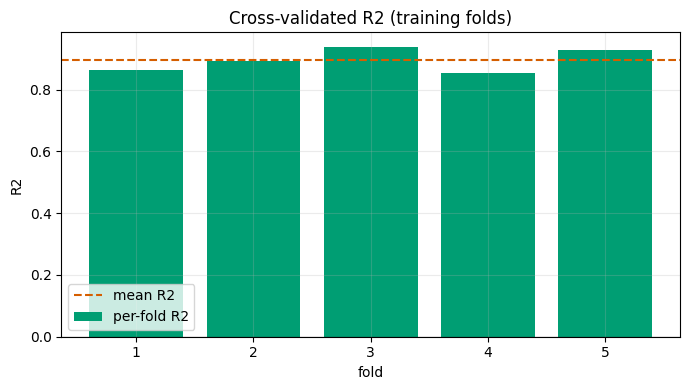

In [6]:
cv_r2 = cross_val_score(LinearRegression(), X_train, y_train,
                        cv=5, scoring='r2')
print('5-fold CV R2 on training data:')
for k, score in enumerate(cv_r2, 1):
    print(f'  fold {k}: {score:.3f}')
print(f'  mean : {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')
print(f'\nFinal held-out test R2 (reported once): {r2_score(y_test, test_pred):.3f}')

plt.figure(figsize=(7, 4))
plt.bar(np.arange(1, 6), cv_r2, color=OKABE_ITO[2], label='per-fold R2')
plt.axhline(cv_r2.mean(), color=OKABE_ITO[3], ls='--', label='mean R2')
plt.axhline(0, color='black', lw=0.8)
plt.title('Cross-validated R2 (training folds)')
plt.xlabel('fold'); plt.ylabel('R2'); plt.legend()
plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## Takeaways
- Split **before** fitting; report metrics on held-out data only.
- R² is relative to a mean baseline and can be negative.
- Cross-validation on training data gauges stability without touching the test set.